In [2]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import pickle
from pandas.api.types import is_numeric_dtype
from sklearn.model_selection import train_test_split
from scipy.stats import mannwhitneyu
from scipy.spatial.distance import cdist
from sklearn.cluster import MiniBatchKMeans
import re

import sklearn, matplotlib, scipy
import tensorflow as tf
from tensorflow import keras

In [3]:
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")
print(f"Matplotlib version: {matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")
print(f"SciPy version: {scipy.__version__}")
print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

NumPy version: 1.24.4
Pandas version: 1.2.4
Scikit-learn version: 1.3.2
Matplotlib version: 3.4.1
Seaborn version: 0.11.1
SciPy version: 1.10.1
TensorFlow version: 2.7.0
Keras version: 2.7.0


In [12]:
# Pandas 출력 옵션 조정 - All
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [15]:
# Pandas 출력 옵션 조정 - Default
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')
pd.reset_option('display.width')
pd.reset_option('display.max_colwidth')

In [4]:
## Definitions

## Defines

# Data confirmmation :: Nan counts + Nan Ratios, Unique values
def analyse_dataframe(df):
    # NaN 개수, 비율 및 고유 값 개수 계산
    nan_counts = df.isnull().sum()
    nan_ratios = df.isnull().mean() * 100  # 백분율로 표시
    unique_values_count = df.nunique()

    # 결과 데이터 프레임 생성
    analysis_result = pd.DataFrame({
        'NaN Counts': nan_counts,
        'NaN Ratios (%)': nan_ratios,
        'Unique Values Count': unique_values_count
    })

    return analysis_result

def print_progress(iteration, total, prefix='', suffix='', decimals=1, length=50, fill='█', printEnd="\r"):
    """
    Call in a loop to create terminal progress bar
    @params:
        iteration   - Required  : current iteration (Int)
        total       - Required  : total iterations (Int)
        prefix      - Optional  : prefix string (Str)
        suffix      - Optional  : suffix string (Str)
        decimals    - Optional  : positive number of decimals in percent complete (Int)
        length      - Optional  : character length of bar (Int)
        fill        - Optional  : bar fill character (Str)
        printEnd    - Optional  : end character (e.g. "\r", "\r\n") (Str)
    """
    percent = ("{0:." + str(decimals) + "f}").format(100 * (iteration / float(total)))
    filledLength = int(length * iteration // total)
    bar = fill * filledLength + '-' * (length - filledLength)
    print(f'\r{prefix} |{bar}| {percent}% {suffix}', end=printEnd)
    # Print New Line on Complete
    if iteration == total: 
        print()

In [5]:
## Configs
base = '/media/bami/d4960d77-e5f3-4877-a333-26e637be3a0e/JHA/24-07_nedis/KNN'
# out = f'{base}/Clustering/M01_Main'
# out = f'{base}/Clustering/M13/1_Whole'
out = f'{base}/Clustering/M15_dataset08/0531~/0711/WholeExp'
ipt = f'{base}/Dataset'
Z_dir = f'{base}/Clustering/M15_dataset08/0531~/0711/WholeExp'

In [6]:
# CLUSTERING :: DATA IMPORT

# Data import
df = pd.read_csv(f"{ipt}/knn_prep-fin_M08.csv")
# df = pd.read_csv(f"{ipt}/knn_prep-fin_M08-alive.csv")
df.rename(columns={'Unnamed: 0': 'idx_code'}, inplace=True)
df.set_index('idx_code', inplace=True)
print(len(df.columns))
df

162


/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3165: DtypeWarning: Columns (22) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


,sex_sys_val,birthdt,bird,admd,apgs1,apgs5,bwei,mage,gran,parn,...,ntetoy_3,ntetoy_1,iperr_1,iperr_2,iperr_3,iperr_4,iperroy_1,iperroy_4,iperroy_3,iperroy_2
idx_code,,,,,,,,,,,,,,,,,,,,,
0,1,2013-12-18,2013-12-18,2013-12-18,4.0,5.0,1350,29,1,0,...,0,0,1,0,0,0,1,0,0,0
1,1,2013-11-15,2013-11-15,2013-11-15,4.0,5.0,790,35,1,0,...,0,0,1,0,0,0,1,0,0,0
2,1,2013-11-15,2013-11-15,2013-11-15,5.0,6.0,1400,26,1,0,...,0,0,1,0,0,0,1,0,0,0
3,1,2013-11-15,2013-11-15,2013-11-15,6.0,7.0,1340,26,1,0,...,0,0,1,0,0,0,1,0,0,0
4,1,2013-11-11,2013-11-11,2013-11-11,4.0,5.0,1240,36,4,1,...,0,0,1,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20408,1,2022-11-28,2022-11-28,2022-11-28,5.0,8.0,1350,23,1,0,...,0,0,1,0,0,0,1,0,0,0
20409,1,2022-12-27,2022-12-27,2022-12-27,4.0,7.0,860,38,3,1,...,0,0,1,0,0,0,1,0,0,0
20410,0,2022-12-01,2022-12-01,2022-12-01,5.0,7.0,1910,30,2,0,...,0,0,1,0,0,0,1,0,0,0


In [7]:
## 특정 칼럼의 값을 가진 인원만 사용

# col_name1 = 'iperr_2'
# col_name2 = 'ntet_1'
col_name = 'ntet_1'
value = 1

# df = df[(df[col_name1] == value) | (df[col_name2] == value)]    # 'OR' condition
df = df[df[col_name] == value]
num_rows = df.shape[0]
num_cols = df.shape[1]
summary_df = pd.DataFrame({
    'n_participants': [num_rows],
    'n_features': [num_cols]
})

file_name = col_name.split('_')[0] + '_Pos_DataSummary'
summary_df.to_csv(f"{out}/{file_name}.csv", index=False)
print(f"Data summary has been saved: {out}/{file_name}.csv")

df

Data summary has been saved: /media/bami/d4960d77-e5f3-4877-a333-26e637be3a0e/JHA/24-07_nedis/KNN/Clustering/M15_dataset08/0531~/0628_Feedback/WholeExp-NTET_Only/ntet_Pos_DataSummary.csv


,sex_sys_val,birthdt,bird,admd,apgs1,apgs5,bwei,mage,gran,parn,...,ntetoy_3,ntetoy_1,iperr_1,iperr_2,iperr_3,iperr_4,iperroy_1,iperroy_4,iperroy_3,iperroy_2
idx_code,,,,,,,,,,,,,,,,,,,,,
3,1,2013-11-15,2013-11-15,2013-11-15,6.0,7.0,1340,26,1,0,...,0,0,1,0,0,0,1,0,0,0
4,1,2013-11-11,2013-11-11,2013-11-11,4.0,5.0,1240,36,4,1,...,0,0,1,0,0,0,1,0,0,0
44,1,2013-07-22,2013-07-22,2013-07-22,1.0,5.0,990,32,1,0,...,0,0,1,0,0,0,1,0,0,0
46,1,2013-10-18,2013-10-18,2013-10-18,9.0,10.0,600,35,1,0,...,0,0,1,0,0,0,1,0,0,0
72,0,2013-07-09,2013-07-09,2013-07-09,1.0,5.0,473,35,1,0,...,1,0,1,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20262,0,2022-01-07,2022-01-07,2022-01-07,6.0,8.0,1090,32,1,0,...,0,0,0,0,0,1,1,0,0,0
20297,1,2022-04-07,2022-04-07,2022-04-07,1.0,6.0,710,31,3,2,...,1,0,1,0,0,0,1,0,0,0
20312,0,2022-09-24,2022-09-24,2022-09-24,5.0,8.0,1260,32,3,0,...,0,0,1,0,0,0,1,0,0,0


In [7]:
for column in data.columns:
    print(f"칼럼 이름: {column}")
    print(f"데이터 타입: {data[column].dtype}")
    print(f"유니크한 값:")
    print(data[column].unique())
    print("-" * 40)

NameError: name 'data' is not defined

In [7]:
## 기존 세팅
# datetime_cols = ['ntetdt', 'ntetdty', 'date362', 'date36', 'menidt', 'pdaddth', 'pdaddt'
#                  , 'acldt', 'birthdt', 'bsfdt1', 'bsfdt3', 'admd'
#                  , 'prho', 'promd', 'promh', 'prdh', 'dth36dt'    # 01-24 추가됨 ('promh', 'prdh', 'dth36dt')
#                  , 'fsfdt1', 'fsfdt2', 'birtm', 'bird']
# drop_cols = ['apguk1', 'apguk5', 'fetc2', 'fetc', 'strduot', 'metc', 'ibifcmt', 'lbpdot'
#              , 'bhdcut', 'bhtcut', 'iperrdt', 'phudot', 'phudstdt', 'sftum', 'sftuh', 'sftfudt'
#              , 'sftthdt', 'birdm', 'birdh', 'sign'
#              , 'promn'    # 01-24 추가됨
#             ]



print(len(df.columns), '\n')

# drop_cols = []    # ~0530
drop_cols = [
#     PDA_7d_NTET
#     PDA_7d_IPERR
#     PDA_7d_IPERRorNTET
#     7d_PDA
#     NTET_day
#     ntet_1
#     ntet_0
#     ntet_Unknown
#     iperr_2
#     iperr_1
#     ntety_2
#     ntety_1
#     ntety_3
#     ntety_4
#     ntetoy_2
#     ntetoy_3
#     ntetoy_1
#     iperr_3
#     iperr_4
#     iperroy_1
#     iperroy_4
#     iperroy_3
#     iperroy_2
#     bdp
#     bdp_Moderate+
#     oxyt36_3
#     oxyt36_2
#     oxyt36_1
#     arre36_6
#     arre36_7
#     arre36_0
#     niarvhfnc
#     pvl_3
#     pvl_1
#     pvl_2
#     seps_3
#     SEPS_bef_NTET
#     SEPS_aft_NTET
#     SEPS_bef_IPERR
#     SEPS_aft_IPERR
#     SEPS_bef_IPERRorNTET
#     SEPS_aft_IPERRorNTET
#     stday
#     death_CR
#     death_NL
#     death_Inf
#     death_GI
#     death_CA
#     death_Otr
    'ga'    # 06/28 added
]
print('len(drop_cols): ', len(drop_cols), '\n')


datetime_cols = ['ntetdt', 'ntetdty', 'date362', 'date36', 'menidt', 'pdaddth', 'pdaddt'
                 , 'birthdt', 'admd', 'birtm', 'bird', 'efydt', 'death_dt', 'iperrdt'
                ]
drop_cols += datetime_cols
print('len(drop_cols): ', len(drop_cols), '\n')


rsndth_cols = ['death_CR', 'death_NL', 'death_Inf', 'death_GI', 'death_CA', 'death_Otr']
drop_cols += rsndth_cols
print('len(drop_cols): ', len(drop_cols))
print("drop_cols:", drop_cols)
# df = df.drop(columns=list(drop_cols))

target_keys = ['ntet_', 'ntety_', 'ntetoy_'
               , 'SEPS_bef_NTET', 'SEPS_aft_NTET'
               , 'NTET_day', 'PDA_7d_NTET'
               , 'invfpod'
               , 'iperr_', 'iperroy_'
               , 'SEPS_bef_IPERR', 'SEPS_aft_IPERR'
               , 'IPERR_day', 'PDA_7d_IPERR', 'PDA_7d_IPERRorNTET'
               , 'SEPS_bef_IPERRorNTET', 'SEPS_aft_IPERRorNTET'
               
               , '7d_PDA'
               , 'bdp', 'bdp_Moderate+', 'strdu_'
               , 'inhg_', 'pvl_', 'nese_'
               , 'seps_3'
               , 'pmirnsg_', 'pmirnsgnd'
               , 'stday'

               , 'oxyt36_', 'arre36_'    # 05/31 Added
               , 'bwei'    # 06/28 added
               , 'btem', 'bhei', 'bhead'    # 07/10 added
              ]
tgt_cols = [col for col in df.columns
            if col in target_keys or any(col.startswith(prefix) for prefix in target_keys)
           ]
print('len(tgt_cols): ', len(tgt_cols))
print("tgt_cols:", tgt_cols)




# tgt_cols = [col for col in df.columns if col in ['ntet', 'ntety', 'ntetoy'
#                                                     , 'SEPS_bef_NTET', 'SEPS_aft_NTET'
#                                                     , 'NTET_day', 'PDA_7d_NTET'
#                                                     , 'invfpod'
#                                                     , 'iperr', 'iperroy'
#                                                     , 'SEPS_bef_IPERR', 'SEPS_aft_IPERR'
#                                                     , 'IPERR_day', 'PDA_7d_IPERR'
#                                                     , 'PDA_7d_IPERRorNTET'
#                                                     , 'SEPS_bef_IPERRorNTET', 'SEPS_aft_IPERRorNTET'
#                                                    ]
#             or any(col.startswith(prefix) for prefix in ['ntet', 'ntety', 'ntetoy'
#                                                          , 'SEPS_bef_NTET', 'SEPS_aft_NTET'
#                                                          , 'NTET_day', 'PDA_7d_NTET'
#                                                          , 'invfpod'
#                                                          , 'iperr', 'iperroy'
#                                                          , 'SEPS_bef_IPERR', 'SEPS_aft_IPERR'
#                                                          , 'IPERR_day', 'PDA_7d_IPERR'
#                                                          , 'PDA_7d_IPERRorNTET'
#                                                          , 'SEPS_bef_IPERRorNTET', 'SEPS_aft_IPERRorNTET'
#                                                         ])
#            ]




data = df.drop(columns=['death_label'] + list(tgt_cols) + list(drop_cols)
#                + list(drop_cols)
#                + list(datetime_cols)
              )
print('len(data): ', len(data.columns), "--> drop(columns=['death_label'] + list(tgt_cols) + list(drop_cols)")

# # 데이터 표준화 (이진 값을 제외하고 표준화 수행)
# scaler = StandardScaler()
# scaled_data = scaler.fit_transform(data)
# df_scd = pd.DataFrame(scaled_data, index=data.index, columns=data.columns)

# df_scd['death_label'] = df['death_label']


binary_cols = []
for col in data.columns:
    unique_vals = set(data[col].dropna().unique())
    if unique_vals.issubset({0, 1}):
        binary_cols.append(col)
continuous_cols = [col for col in data.columns if col not in binary_cols]

print("Binary cols:", len(binary_cols))
for col in binary_cols:
    print(f"- {col}")
print("\nContinuous cols:", len(continuous_cols))
for col in continuous_cols:
    print(f"- {col}")
print('len(data): ', len(data.columns))


scaler = StandardScaler()
scaled_data = scaler.fit_transform(data[continuous_cols])
df_scd = pd.concat([
    pd.DataFrame(scaled_data, index=data.index, columns=continuous_cols),
    data[binary_cols]
], axis=1)
df_scd = df_scd[data.columns]

df_scd['death_label'] = df['death_label']
df_scd

162 

len(drop_cols):  1 

len(drop_cols):  15 

len(drop_cols):  21
drop_cols: ['ga', 'ntetdt', 'ntetdty', 'date362', 'date36', 'menidt', 'pdaddth', 'pdaddt', 'birthdt', 'admd', 'birtm', 'bird', 'efydt', 'death_dt', 'iperrdt', 'death_CR', 'death_NL', 'death_Inf', 'death_GI', 'death_CA', 'death_Otr']
len(tgt_cols):  62
tgt_cols: ['bwei', 'bhei', 'bheiuk', 'bhead', 'bheaduk', 'btem', 'btemuk', 'invfpod', 'pmirnsgnd', 'stday', 'PDA_7d_NTET', 'PDA_7d_IPERR', '7d_PDA', 'PDA_7d_IPERRorNTET', 'SEPS_bef_NTET', 'SEPS_aft_NTET', 'SEPS_bef_IPERR', 'SEPS_aft_IPERR', 'SEPS_bef_IPERRorNTET', 'SEPS_aft_IPERRorNTET', 'NTET_day', 'IPERR_day', 'strdu_1', 'strdu_0', 'nese_1', 'nese_0', 'ntet_1', 'ntet_0', 'ntet_Unknown', 'pmirnsg_0', 'pmirnsg_1+', 'inhg_0', 'inhg_1', 'inhg_2+', 'inhg_3+', 'bdp', 'bdp_Moderate+', 'oxyt36_1', 'oxyt36_2', 'oxyt36_3', 'arre36_0', 'arre36_6', 'arre36_7', 'pvl_1', 'pvl_3', 'pvl_2', 'seps_3', 'ntety_1', 'ntety_2', 'ntety_3', 'ntety_4', 'ntetoy_2', 'ntetoy_3', 'ntetoy_1', 'iper

,sex_sys_val,apgs1,apgs5,mage,gran,parn,bbph,bbphuk,bbbe,bbbeuk,...,oxyt28_1,oxyt28_3,oxyt28_2,oxyt28_4,arre28_0,arre28_6,arre28_7,seps_1,seps_2,death_label
idx_code,,,,,,,,,,,,,,,,,,,,,
0,1,-0.361034,-1.032974,-1.020264,-0.760507,-0.636012,0.862903,0.0,-0.064258,0.0,...,1,0,0,0,1,0,0,1,0,0
1,1,-0.361034,-1.032974,0.360486,-0.760507,-0.636012,0.179879,0.0,-0.064258,0.0,...,0,1,0,0,0,1,0,0,1,0
2,1,0.117458,-0.497525,-1.710639,-0.760507,-0.636012,1.545927,0.0,0.891358,0.0,...,1,0,0,0,1,0,0,1,0,0
3,1,0.595950,0.037925,-1.710639,-0.760507,-0.636012,2.228951,0.0,1.740794,0.0,...,1,0,0,0,1,0,0,0,1,0
4,1,-0.361034,-1.032974,0.590611,1.748735,0.768667,0.960478,0.0,0.307370,0.0,...,1,0,0,0,0,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20408,1,0.117458,0.573375,-2.401014,-0.760507,-0.636012,0.277454,0.0,-0.515521,0.0,...,1,0,0,0,1,0,0,0,1,0
20409,1,-0.361034,0.037925,1.050861,0.912321,0.768667,-0.112846,0.0,0.280825,0.0,...,0,1,0,0,0,1,0,0,1,0
20410,0,0.117458,0.037925,-0.790139,0.075907,-0.636012,0.472603,0.0,0.546274,0.0,...,0,0,1,0,1,0,0,1,0,0


In [8]:
print(len(drop_cols))
print(len(datetime_cols))
print(len(tgt_cols))
tgt_cols

21
14
62


['bwei',
 'bhei',
 'bheiuk',
 'bhead',
 'bheaduk',
 'btem',
 'btemuk',
 'invfpod',
 'pmirnsgnd',
 'stday',
 'PDA_7d_NTET',
 'PDA_7d_IPERR',
 '7d_PDA',
 'PDA_7d_IPERRorNTET',
 'SEPS_bef_NTET',
 'SEPS_aft_NTET',
 'SEPS_bef_IPERR',
 'SEPS_aft_IPERR',
 'SEPS_bef_IPERRorNTET',
 'SEPS_aft_IPERRorNTET',
 'NTET_day',
 'IPERR_day',
 'strdu_1',
 'strdu_0',
 'nese_1',
 'nese_0',
 'ntet_1',
 'ntet_0',
 'ntet_Unknown',
 'pmirnsg_0',
 'pmirnsg_1+',
 'inhg_0',
 'inhg_1',
 'inhg_2+',
 'inhg_3+',
 'bdp',
 'bdp_Moderate+',
 'oxyt36_1',
 'oxyt36_2',
 'oxyt36_3',
 'arre36_0',
 'arre36_6',
 'arre36_7',
 'pvl_1',
 'pvl_3',
 'pvl_2',
 'seps_3',
 'ntety_1',
 'ntety_2',
 'ntety_3',
 'ntety_4',
 'ntetoy_2',
 'ntetoy_3',
 'ntetoy_1',
 'iperr_1',
 'iperr_2',
 'iperr_3',
 'iperr_4',
 'iperroy_1',
 'iperroy_4',
 'iperroy_3',
 'iperroy_2']

In [9]:
for column in df.columns:
    print(f"칼럼 이름: {column}")
    print(f"데이터 타입: {df[column].dtype}")
    print(f"유니크한 값:")
    print(df[column].unique())
    print("-" * 40)

칼럼 이름: sex_sys_val
데이터 타입: int64
유니크한 값:
[1 0]
----------------------------------------
칼럼 이름: birthdt
데이터 타입: object
유니크한 값:
['2013-12-18' '2013-11-15' '2013-11-11' ... '2022-05-05' '2022-07-09'
 '2022-06-19']
----------------------------------------
칼럼 이름: bird
데이터 타입: object
유니크한 값:
['2013-12-18' '2013-11-15' '2013-11-11' ... '2022-05-05' '2022-07-09'
 '2022-06-19']
----------------------------------------
칼럼 이름: admd
데이터 타입: object
유니크한 값:
['2013-12-18' '2013-11-15' '2013-11-11' ... '2022-05-05' '2022-07-09'
 '2022-06-19']
----------------------------------------
칼럼 이름: apgs1
데이터 타입: float64
유니크한 값:
[ 4.          5.          6.          3.          7.          1.
  9.          8.          2.          4.75271096  0.         10.        ]
----------------------------------------
칼럼 이름: apgs5
데이터 타입: float64
유니크한 값:
[ 5.          6.          7.          8.          4.          9.
  1.          3.         10.          2.          6.92736054  0.        ]
---------------------------------

In [10]:
analyse_dataframe(df)

,NaN Counts,NaN Ratios (%),Unique Values Count
sex_sys_val,0,0.0,2
birthdt,0,0.0,3591
bird,0,0.0,3591
admd,0,0.0,3592
apgs1,0,0.0,12
...,...,...,...
iperr_4,0,0.0,2
iperroy_1,0,0.0,2
iperroy_4,0,0.0,2
iperroy_3,0,0.0,2


In [11]:
analyse_dataframe(df_scd)

,NaN Counts,NaN Ratios (%),Unique Values Count
sex_sys_val,0,0.0,2
apgs1,0,0.0,12
apgs5,0,0.0,12
mage,0,0.0,40
gran,0,0.0,16
...,...,...,...
arre28_6,0,0.0,2
arre28_7,0,0.0,2
seps_1,0,0.0,2
seps_2,0,0.0,2


In [12]:
for column in df_scd.columns:
    print(f"칼럼 이름: {column}")
    print(f"데이터 타입: {df_scd[column].dtype}")
    print(f"유니크한 값:")
    print(df_scd[column].unique())
    print("-" * 40)

칼럼 이름: sex_sys_val
데이터 타입: int64
유니크한 값:
[1 0]
----------------------------------------
칼럼 이름: apgs1
데이터 타입: float64
유니크한 값:
[-3.61033760e-01  1.17458148e-01  5.95950057e-01 -8.39525668e-01
  1.07444196e+00 -1.79650948e+00  2.03142578e+00  1.55293387e+00
 -1.31801758e+00 -8.67655096e-04 -2.27500139e+00  2.50991769e+00]
----------------------------------------
칼럼 이름: apgs5
데이터 타입: float64
유니크한 값:
[-1.03297435e+00 -4.97524662e-01  3.79250240e-02  5.73374710e-01
 -1.56842403e+00  1.10882440e+00 -3.17477309e+00 -2.10387372e+00
  1.64427408e+00 -2.63932340e+00 -9.69754067e-04 -3.71022278e+00]
----------------------------------------
칼럼 이름: mage
데이터 타입: float64
유니크한 값:
[-1.02026381  0.3604862  -1.71063881  0.5906112  -0.3298888   1.97136121
 -0.0997638  -0.79013881 -0.5600138  -1.25038881  0.82073621  0.1303612
  1.74123621 -1.94076382 -3.09138882  1.05086121  1.28098621 -1.48051381
 -2.17088882 -3.32151383  2.20148622 -2.86126382 -2.40101382  1.51111121
 -2.63113882  2.43161122  3.12198622 

In [13]:
# ntet_1
# iperr_2
# death36

# 생존과 사망 비율 계산 (%)
death_label_ratio = df['iperr_2'].value_counts(normalize=True) * 100
# 생존(0)과 사망(1) 비율 각각 출력
survived_ratio = death_label_ratio[0]  # 생존 비율
died_ratio = death_label_ratio[1]      # 사망 비율
# 출력
print("[1-1, IPERR POS]")
print("[df_scd (Processed df)]")
print(f"Negatives (0): {survived_ratio:.2f}%")
print(f"Negatives / Total : {len(df[df['iperr_2'] == 0])} / {len(df['iperr_2'])}")
print("&")
print(f"Positives (1): {died_ratio:.2f}%")
print(f"Positives / Total : {len(df[df['iperr_2'] == 1])} / {len(df['iperr_2'])}")
print()


# 생존과 사망 비율 계산 (%)
death_label_ratio = df['ntet_1'].value_counts(normalize=True) * 100
# 생존(0)과 사망(1) 비율 각각 출력
survived_ratio = death_label_ratio[0]  # 생존 비율
died_ratio = death_label_ratio[1]      # 사망 비율
# 출력
print("[1-2, NTET POS]")
print("[df_scd (Processed df)]")
print(f"Negatives (0): {survived_ratio:.2f}%")
print(f"Negatives / Total : {len(df[df['ntet_1'] == 0])} / {len(df['ntet_1'])}")
print("&")
print(f"Positives (1): {died_ratio:.2f}%")
print(f"Positives / Total : {len(df[df['ntet_1'] == 1])} / {len(df['ntet_1'])}")
print()



# 생존과 사망 비율 계산 (%)
death_label_ratio = df['death_label'].value_counts(normalize=True) * 100
# 생존(0)과 사망(1) 비율 각각 출력
survived_ratio = death_label_ratio[0]  # 생존 비율
died_ratio = death_label_ratio[1]      # 사망 비율
# 출력
print("[2]")
print("[df_scd (Processed df)]")
print(f"Survived (0): {survived_ratio:.2f}%")
print(f"Survived / Total : {len(df[df['death_label'] == 0])} / {len(df['death_label'])}")
print("&")
print(f"Died (1): {died_ratio:.2f}%")
print(f"Death / Total : {len(df[df['death_label'] == 1])} / {len(df['death_label'])}")
print()





## IPERR + NTET BOTH
conditioned_participants = len(df[(df['iperr_2'] == 1) & (df['ntet_1'] == 1)])
# 전체 데이터의 인원 수
total_participants = len(df)
# 조건에 맞는 데이터의 전체 데이터 대비 비율
conditioned_ratio = (conditioned_participants / total_participants) * 100
# 출력
print("[IPERR+NTET BOTH]")
print("[df_scd (Processed df)]")
print(f"Conditioned Participants (1 in both iperr_2 and ntet_1): {conditioned_participants}")
print(f"Conditioned Participants / Total : {conditioned_participants} / {total_participants} ({conditioned_ratio:.2f}%)")


[1-1, IPERR POS]
[df_scd (Processed df)]
Negatives (0): 97.75%
Negatives / Total : 19894 / 20352
&
Positives (1): 2.25%
Positives / Total : 458 / 20352

[1-2, NTET POS]
[df_scd (Processed df)]
Negatives (0): 93.70%
Negatives / Total : 19070 / 20352
&
Positives (1): 6.30%
Positives / Total : 1282 / 20352

[2]
[df_scd (Processed df)]
Survived (0): 87.27%
Survived / Total : 17761 / 20352
&
Died (1): 12.73%
Death / Total : 2591 / 20352

[IPERR+NTET BOTH]
[df_scd (Processed df)]
Conditioned Participants (1 in both iperr_2 and ntet_1): 146
Conditioned Participants / Total : 146 / 20352 (0.72%)


In [14]:
df_scd

,sex_sys_val,apgs1,apgs5,mage,gran,parn,bbph,bbphuk,bbbe,bbbeuk,...,oxyt28_1,oxyt28_3,oxyt28_2,oxyt28_4,arre28_0,arre28_6,arre28_7,seps_1,seps_2,death_label
idx_code,,,,,,,,,,,,,,,,,,,,,
0,1,-0.361034,-1.032974,-1.020264,-0.760507,-0.636012,0.862903,0.0,-0.064258,0.0,...,1,0,0,0,1,0,0,1,0,0
1,1,-0.361034,-1.032974,0.360486,-0.760507,-0.636012,0.179879,0.0,-0.064258,0.0,...,0,1,0,0,0,1,0,0,1,0
2,1,0.117458,-0.497525,-1.710639,-0.760507,-0.636012,1.545927,0.0,0.891358,0.0,...,1,0,0,0,1,0,0,1,0,0
3,1,0.595950,0.037925,-1.710639,-0.760507,-0.636012,2.228951,0.0,1.740794,0.0,...,1,0,0,0,1,0,0,0,1,0
4,1,-0.361034,-1.032974,0.590611,1.748735,0.768667,0.960478,0.0,0.307370,0.0,...,1,0,0,0,0,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20408,1,0.117458,0.573375,-2.401014,-0.760507,-0.636012,0.277454,0.0,-0.515521,0.0,...,1,0,0,0,1,0,0,0,1,0
20409,1,-0.361034,0.037925,1.050861,0.912321,0.768667,-0.112846,0.0,0.280825,0.0,...,0,1,0,0,0,1,0,0,1,0
20410,0,0.117458,0.037925,-0.790139,0.075907,-0.636012,0.472603,0.0,0.546274,0.0,...,0,0,1,0,1,0,0,1,0,0


In [14]:
'''
## 각 클러스터에 헤딩하는 인원들만 선별해 클러스터링

re = f'{out}/C4'
df = pd.read_csv((f"{re}/df_scd_clustered.csv"))
df.set_index('idx_code', inplace=True)

# 특정 클러스터 라벨만 사용
selected_clusters = [1, 2]

df = df[df['Cluster_Labels'].isin(selected_clusters)]
df = df.drop(columns=['Cluster_Labels'])

df_scd = df.copy()
df_scd
'''

'\n## 각 클러스터에 헤딩하는 인원들만 선별해 클러스터링\n\nre = f\'{out}/C4\'\ndf = pd.read_csv((f"{re}/df_scd_clustered.csv"))\ndf.set_index(\'idx_code\', inplace=True)\n\n# 특정 클러스터 라벨만 사용\nselected_clusters = [1, 2]\n\ndf = df[df[\'Cluster_Labels\'].isin(selected_clusters)]\ndf = df.drop(columns=[\'Cluster_Labels\'])\n\ndf_scd = df.copy()\ndf_scd\n'

In [155]:
'''
##### ### # 클러스터링 이후 기존 df를 새로 인가해줘야 함 ! !!! !!!!!

# Data import
df = pd.read_csv(f"{re}/KNN_df_combined.csv")
df.set_index('idx_code', inplace=True)

df = df[df['Cluster_Labels'].isin(selected_clusters)]
original_cluster_labels = df['Cluster_Labels']
df = df.drop(columns=['Cluster_Labels'])
df
'''

/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3165: DtypeWarning: Columns (46,69,72,73) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


,sex_sys_val,birthdt,bir1,bir2,bir3,bir4,promd,prho,promh,prdh,...,ntetoy_3,ntetoy_1,iperr_1,iperr_2,iperr_3,iperr_4,iperroy_1,iperroy_4,iperroy_3,iperroy_2
idx_code,,,,,,,,,,,,,,,,,,,,,
1,1,2013-11-15,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,...,0,0,1,0,0,0,1,0,0,0
3,1,2013-11-15,0.0,1.0,0.0,0.0,NaN,NaN,0.0,0.0,...,0,0,1,0,0,0,1,0,0,0
7,1,2013-10-08,0.0,0.0,0.0,0.0,2013-10-07,18:00,0.0,0.0,...,0,0,1,0,0,0,1,0,0,0
8,0,2013-09-15,0.0,1.0,0.0,0.0,NaN,NaN,0.0,0.0,...,0,0,1,0,0,0,1,0,0,0
10,0,2013-09-25,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,...,0,0,1,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20401,0,2022-08-29,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,...,0,0,1,0,0,0,1,0,0,0
20406,1,2022-11-10,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,...,0,0,1,0,0,0,1,0,0,0
20407,1,2022-11-06,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,...,0,0,1,0,0,0,1,0,0,0


In [14]:
for column in df_tmp.columns:
    print(f"칼럼 이름: {column}")
    print(f"데이터 타입: {df_tmp[column].dtype}")
    print(f"유니크한 값:")
    print(df_tmp[column].unique())
    print("-" * 40)

NameError: name 'df_tmp' is not defined

In [15]:
save_dir = out

In [34]:
## WCSS_scores (MiniBatch K-means)

/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1934: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=3)
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7feada7551f0>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.g

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7feada755ee0>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _Thread

/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1934: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=3)
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7feada755ee0>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.g

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7feada755ee0>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _Thread

/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1934: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=3)
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7feada755f70>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.g

...

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7feada755f70>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _Thread

    self.version = self.get_version()
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1934: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=3)
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7feada7559d0>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7feada7559d0>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _Thread

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7feada755b80>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/sklearn

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7feada755b80>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _Thread

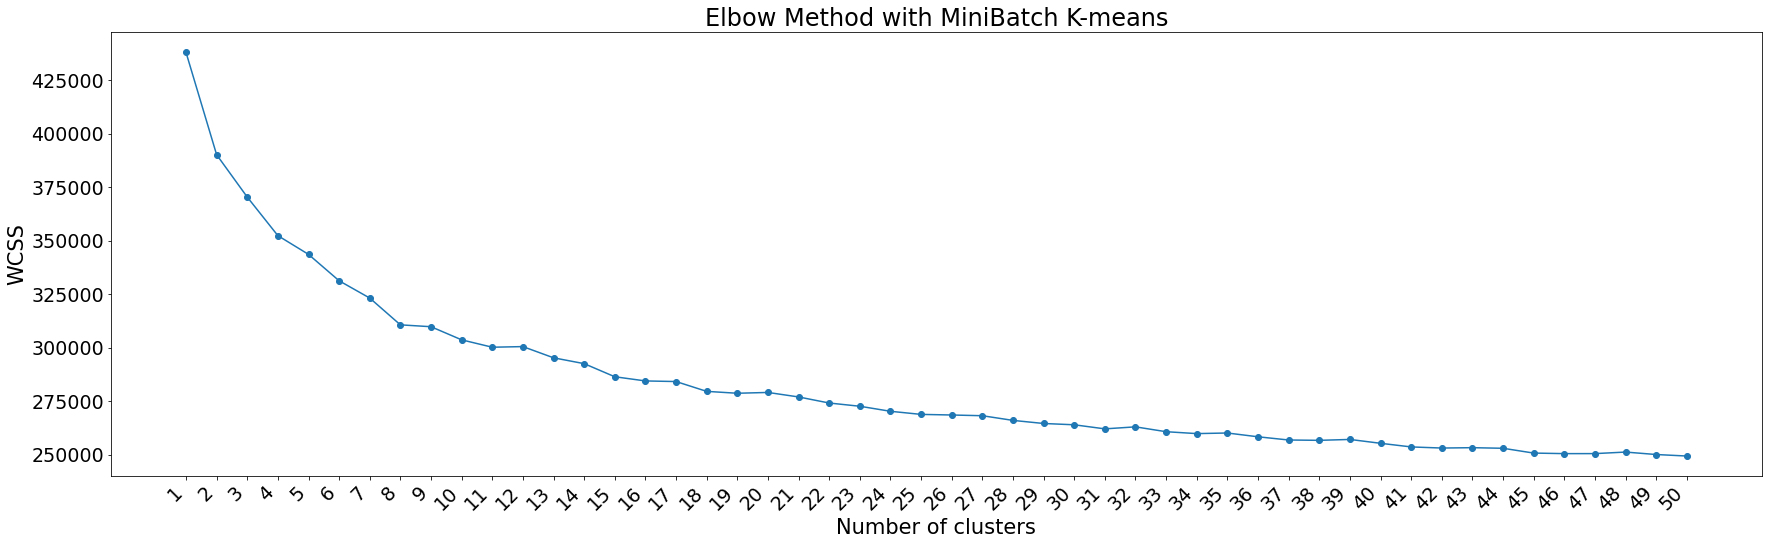

In [15]:
# df1 = pd.read_csv(os.path.join(data, "prep_origin_scd.csv"))
# df1 = df1.drop(columns=['Unnamed: 0'])

df_tmp = df_scd.copy()
# na_cols = df_tmp.isna().sum()
# na_cols = na_cols[na_cols > 0].sort_values(ascending=False)
# print("#### 결측값이 존재하는 컬럼:")
# print(na_cols)


mean_survived = df_tmp.loc[df_tmp['death_label'] == 0, 'EFYN_day'].mean()
mean_dead     = df_tmp.loc[df_tmp['death_label'] == 1, 'EFYN_day'].mean()
mean_avg = (mean_survived + mean_dead) / 2
df_tmp['EFYN_day'] = df_tmp['EFYN_day'].fillna(mean_avg)

data_for_clustering = df_tmp.drop(columns=['death_label'])

data = data_for_clustering

# Initialise list(WCSS)
wcss = []

# MiniBatch KMeans 클러스터링 실행 및 WCSS 계산
for i in range(1, 51):
    minibatch_kmeans = MiniBatchKMeans(n_clusters=i, batch_size=100, random_state=42)
    minibatch_kmeans.fit(data)
    wcss.append(minibatch_kmeans.inertia_)

font_size = 21
plt.rcParams.update({
    'font.size': font_size
    , 'axes.titlesize': font_size + 3
    , 'axes.labelsize': font_size
    , 'xtick.labelsize': font_size - 2
    , 'ytick.labelsize': font_size - 2
    , 'legend.fontsize': font_size - 2
})

# 그래프 생성
plt.figure(figsize=(25, 8))
plt.plot(range(1, 51), wcss, marker='o')
plt.title('Elbow Method with MiniBatch K-means')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')

# X축 레이블을 클러스터 수와 WCSS 값을 포함한 괄호 형식으로 출력
x_labels = [f'{i}' for i, w in enumerate(wcss, 1)]    #  \n ({w:.2f}) for i, w in enumerate(wcss, 1)
plt.xticks(range(1, 51), x_labels, rotation=45, ha='right')  # 49도 회전 및 오른쪽 정렬

# 그래프 표시
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "WCSS_plot.png"))
plt.show()

In [16]:
wcss

[438142.97617702646,
 390263.64383560006,
 370451.4348996549,
 352408.8987789326,
 343648.7573099397,
 331301.8004374272,
 323215.6393574618,
 310691.65751548315,
 309813.60208145936,
 303676.81146164925,
 300222.6847321745,
 300519.52636533923,
 295276.66684365546,
 292541.24005300977,
 286411.74983077816,
 284457.05431328533,
 284171.37959221913,
 279577.1494352081,
 278696.4142752211,
 279072.20145404426,
 276969.3582842052,
 274126.76537070784,
 272617.3695175924,
 270257.88004251197,
 268810.3504857962,
 268527.08805192646,
 268186.661368411,
 266003.4900145803,
 264555.6325930158,
 263948.2631546745,
 262039.4826036251,
 262980.90569662384,
 260710.745505421,
 259823.238050027,
 260105.12348597375,
 258331.96219249105,
 256833.1718263169,
 256675.14696303775,
 257093.9463217511,
 255290.3096421631,
 253592.72334140752,
 253073.1312428719,
 253240.09294860132,
 252959.9125678084,
 250715.51283009615,
 250459.9801529747,
 250465.14641986645,
 251189.31788787944,
 250041.30917505122

In [19]:
# n_out = f'{out}/NTET_Pos'
# save_dir = n_out

In [ ]:
# CLUSTERING :: HIERARCHICAL

Index(['sex_sys_val', 'apgs1', 'apgs5', 'mage', 'gran', 'parn', 'bbph',
       'bbphuk', 'bbbe', 'bbbeuk', 'sftun', 'iarvppd', 'niarvrpd', 'aoxyuppd',
       'niarvhfnc', 'pda_non-treatment', 'pda_unknown', 'PDA_TRD', 'PPHN',
       'EFYN_day', 'ph_1', 'lbp_1', 'lbp_0', 'chor_1', 'chor_0',
       'chor_Unknown', 'ster_1', 'ster_0', 'ster_Unknown', 'atbyn_1',
       'atbyn_0', 'atbyn_Unknown', 'resu_1', 'resu_0', 'resu_Unknown', 'als_1',
       'als_0', 'mph_1', 'mph_0', 'sft_1', 'sft_0', 'ibif_1', 'ibif_0',
       'meni_1', 'meni_0', 'prom_1', 'prom_0', 'prom_Unknown', 'eythtran_1',
       'eythtran_0', 'efyn', 'mulg_singleton', 'mulg_multiple', 'dm_0', 'dm_1',
       'delm_1', 'delm_2', 'prep_1', 'prep_2', 'htn_2', 'htn_1', 'htn_3',
       'amni_1', 'amni_2', 'amni_4', 'amni_3', 'bpia_1', 'bpia_2', 'bpia_3',
       'oxyt28_1', 'oxyt28_3', 'oxyt28_2', 'oxyt28_4', 'arre28_0', 'arre28_6',
       'arre28_7', 'seps_1', 'seps_2', 'death_label'],
      dtype='object') 79
Index(['sex_sys_val'

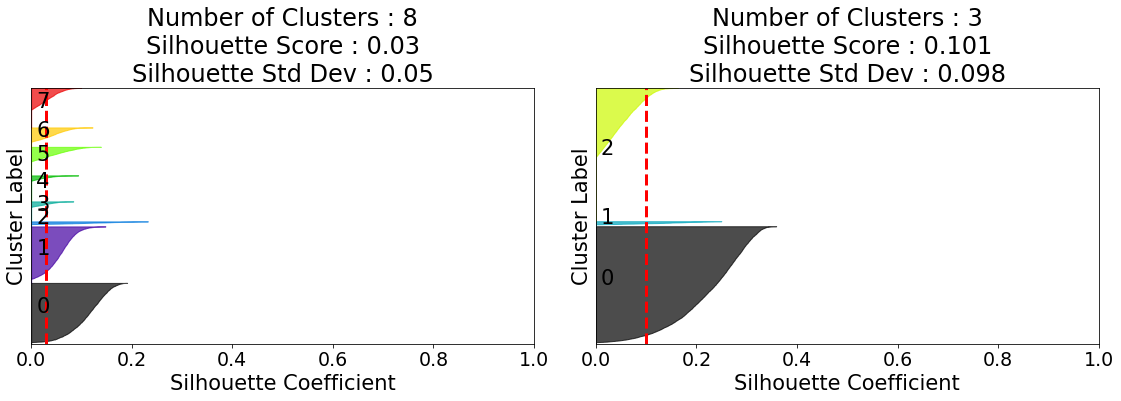

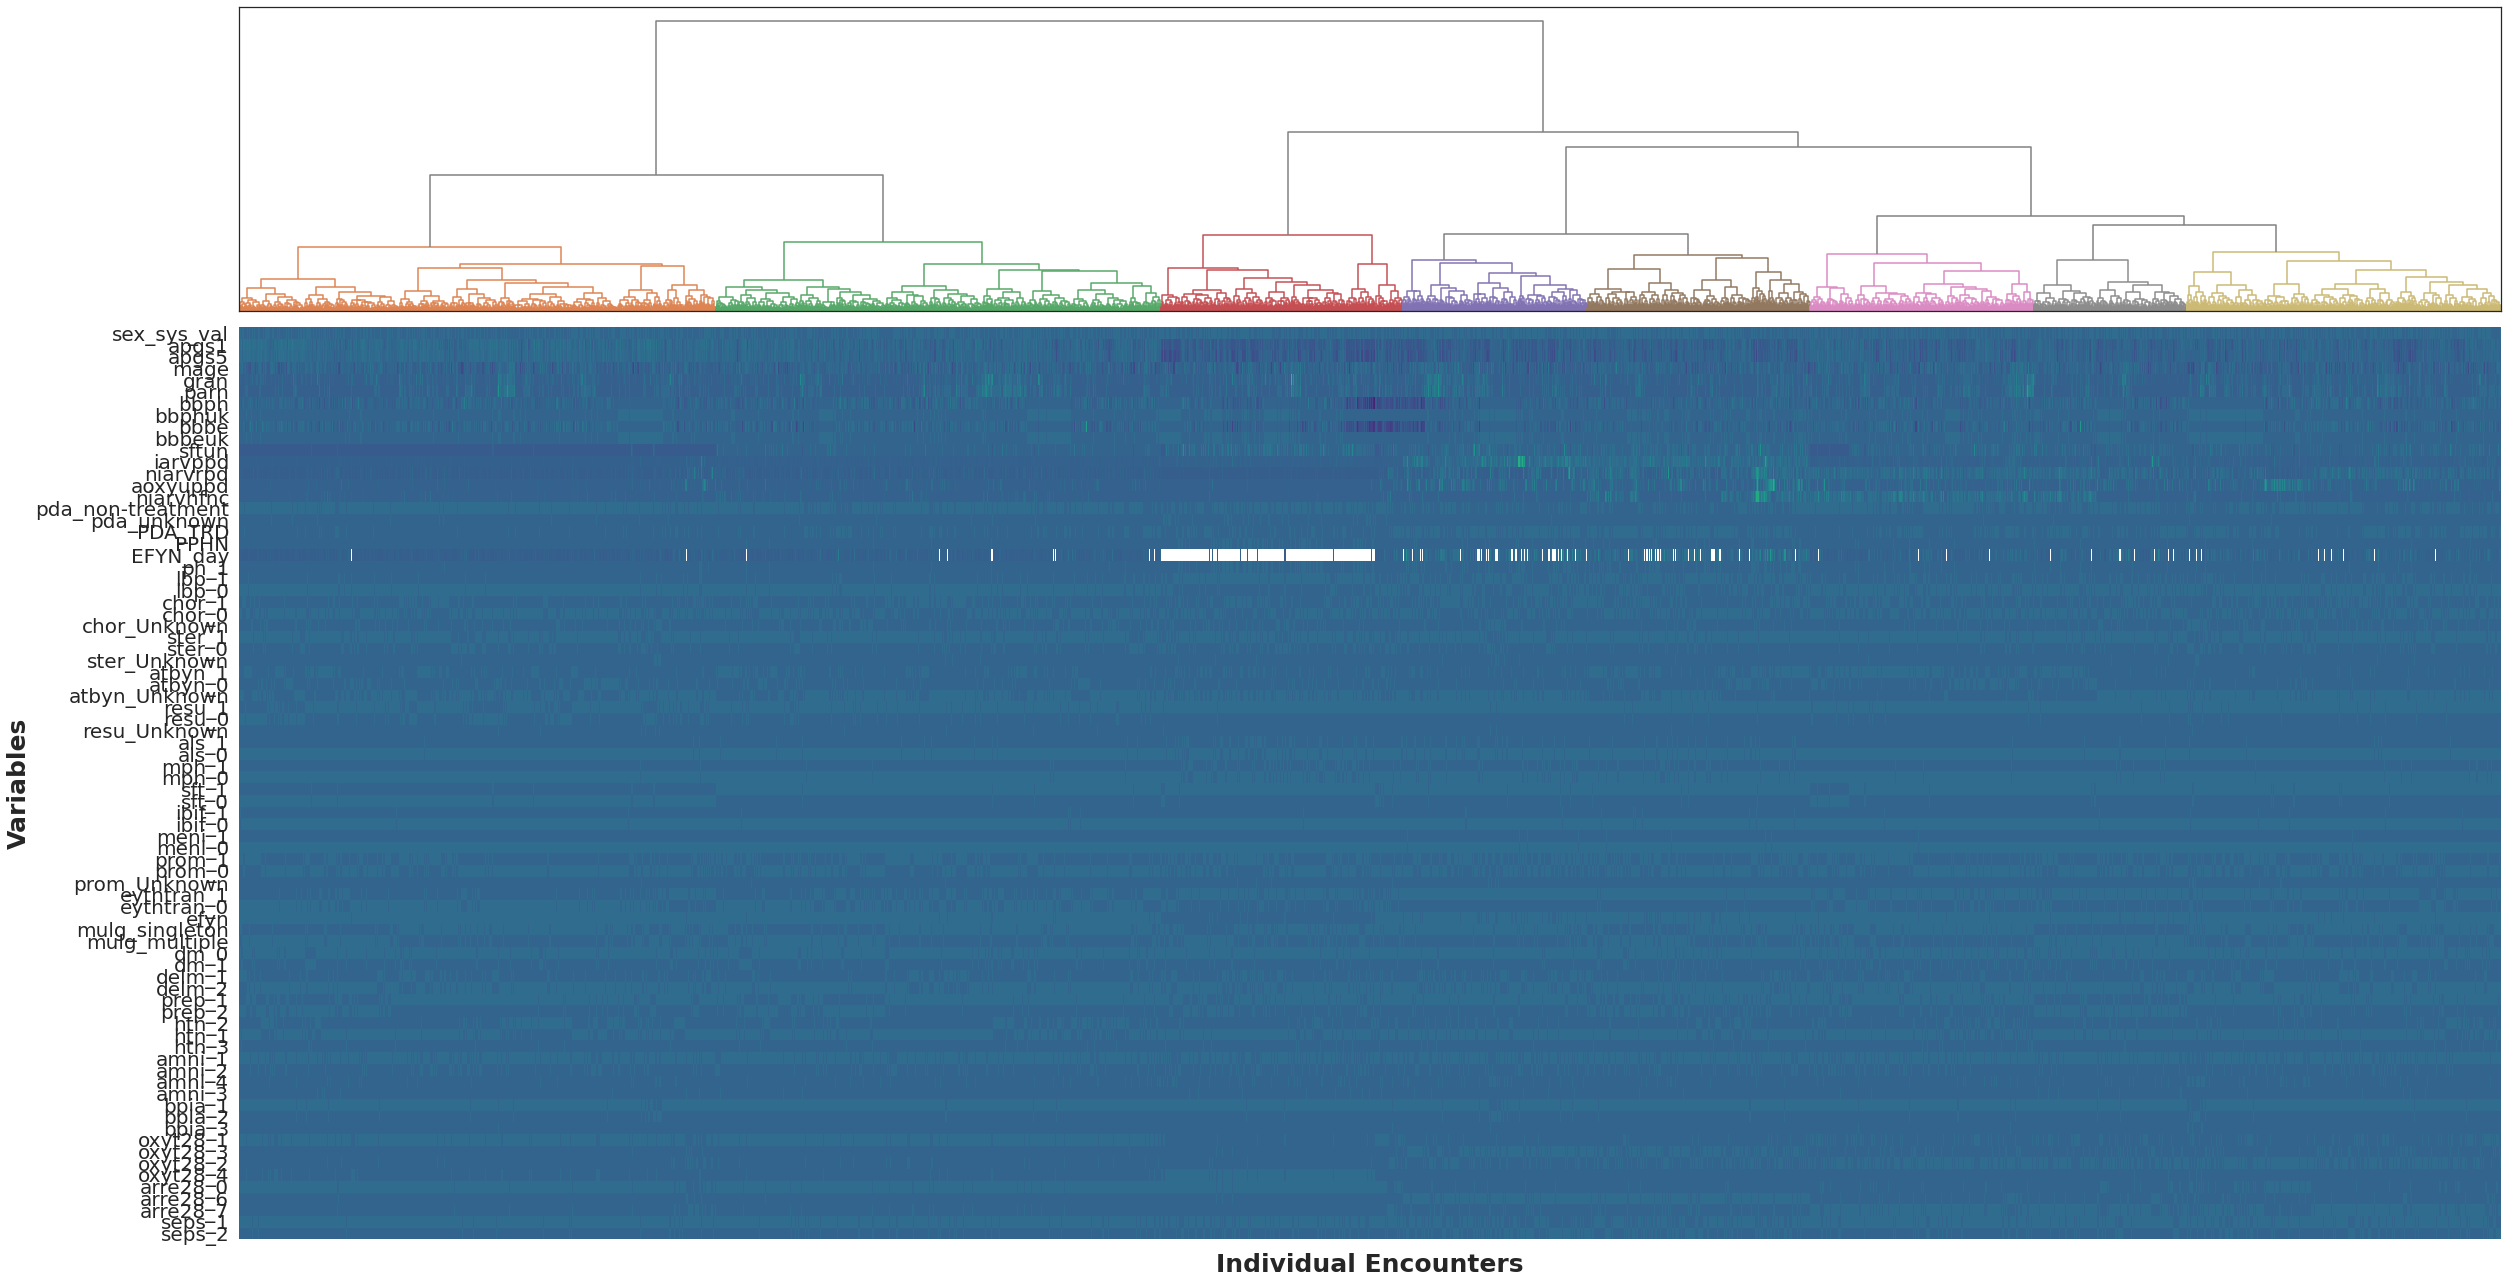

Dendrogram + Heatmap saved: path : /media/bami/d4960d77-e5f3-4877-a333-26e637be3a0e/JHA/24-07_nedis/KNN/Clustering/M15_dataset08/0531~/0711/WholeExp/cluster_analysis_scd.png
Clustering completed with SCALED data.
          sex_sys_val     apgs1     apgs5      mage      gran      parn  \
idx_code                                                                  
0                   1 -0.361034 -1.032974 -1.020264 -0.760507 -0.636012   
1                   1 -0.361034 -1.032974  0.360486 -0.760507 -0.636012   
2                   1  0.117458 -0.497525 -1.710639 -0.760507 -0.636012   
3                   1  0.595950  0.037925 -1.710639 -0.760507 -0.636012   
4                   1 -0.361034 -1.032974  0.590611  1.748735  0.768667   
...               ...       ...       ...       ...       ...       ...   
20408               1  0.117458  0.573375 -2.401014 -0.760507 -0.636012   
20409               1 -0.361034  0.037925  1.050861  0.912321  0.768667   
20410               0  0.117458  0.03

In [17]:
data_for_clustering = df_scd.drop(columns=['death_label'])
print(df_scd.columns, len(df_scd.columns))
print(data_for_clustering.columns, len(data_for_clustering.columns))


# 사용자 정의 Gower 거리 계산 함수
def gower_distance_custom(X):
    """Custom Gower distance computation that ignores NaN values and does not normalize numerical differences."""
#     n_samples, n_features = X.shape
#     G = np.zeros((n_samples, n_samples))
    
#     for i in range(n_features):
#         feature = X[:, i]
#         if np.issubdtype(feature.dtype, np.number):
#             # 수치형 피쳐: 정규화 없이 절대 차이 사용
#             diff_matrix = np.abs(feature - feature.reshape(-1, 1))
#             diff_matrix[np.isnan(diff_matrix)] = 0  # NaN은 무시
#             G += diff_matrix
#         else:
#             # 범주형 피쳐: 동일하지 않으면 1, 동일하면 0
#             feature = feature.astype(str)
#             diff_matrix = (feature != feature.reshape(-1, 1)).astype(float)
#             diff_matrix[np.isnan(diff_matrix)] = 0  # NaN은 무시
#             G += diff_matrix
    
#     # 피쳐 수로 나누어 평균을 구함
#     G /= n_features
#     return G
    n_samples, n_features = X.shape
    
    # G[row, col]: 샘플 row와 col 간 '거리 합'
    G = np.zeros((n_samples, n_samples), dtype=float)
    # valid[row, col]: 결측 없이 비교가 가능한(둘 다 관측된) 변수 개수
    valid = np.zeros((n_samples, n_samples), dtype=float)
    
    for feat_idx in range(n_features):
        col_data = X[:, feat_idx]
        
        # 수치형 변수인지 판별
        if np.issubdtype(col_data.dtype, np.number):
            # 결측 여부
            not_nan_mask = ~np.isnan(col_data)
            
            for row in range(n_samples):
                for col in range(row + 1, n_samples):
                    # 둘 다 관측된 경우에만 거리 계산
                    if not_nan_mask[row] and not_nan_mask[col]:
                        dist_val = abs(col_data[row] - col_data[col])
                        G[row, col] += dist_val
                        G[col, row] += dist_val
                        valid[row, col] += 1
                        valid[col, row] += 1
                        
        else:
            # 범주형 변환 (NaN 처리 위해 object로)
            col_str = col_data.astype('O')  
            # non-null 마스크
            not_nan_mask = pd.notna(col_str)
            
            for row in range(n_samples):
                for col in range(row + 1, n_samples):
                    if not_nan_mask[row] and not_nan_mask[col]:
                        # 둘 다 관측이면
                        dist_val = 0.0 if col_str[row] == col_str[col] else 1.0
                        G[row, col] += dist_val
                        G[col, row] += dist_val
                        valid[row, col] += 1
                        valid[col, row] += 1
    
    # 유효 변수만큼 나누어 평균화
    for row in range(n_samples):
        for col in range(n_samples):
            if valid[row, col] > 0:
                G[row, col] /= valid[row, col]
            else:
                # valid=0인 경우, 둘 다 모든 변수 결측 -> 거리=0 (또는 np.nan)
                G[row, col] = 0.0
    
    return G

# 클러스터링 데이터를 넘파이 배열로 변환
X = data_for_clustering.to_numpy()

# 사용자 정의 Gower 거리 계산
print("Calculating Gower distance matrix...")
distance_matrix = gower_distance_custom(X)
print("Distance matrix calculation completed.")

# Condensed 거리 행렬 생성
distance_matrix_condensed = squareform(distance_matrix)  # 비대각 성분만 추출

# 계층적 클러스터링 수행
print("Performing hierarchical clustering...")
# Z_objects = linkage(distance_matrix_condensed, method='ward')
Z_objects = linkage(distance_matrix_condensed, method='ward')    # Ward method applied
print("Hierarchical clustering completed.")

# Z_objects를 저장
with open(os.path.join(save_dir, "Z_objects.pkl"), "wb") as f:
    pickle.dump(Z_objects, f)

# 실루엣 점수 및 표준 편차 계산
print("Calculating silhouette scores using precomputed Gower distance...")
silhouette_scores = []
silhouette_std_devs = []
range_n_clusters = list(range(2, 10))

for n_clusters in range_n_clusters:
    # 군집 레이블
    cluster_labels = fcluster(Z_objects, t=n_clusters, criterion='maxclust')
    
    # silhouette_samples() 호출 시 metric='precomputed' -> X가 '거리 행렬'이어야 함
    # distance_matrix: (n_samples x n_samples) 형태
    sil_values = silhouette_samples(distance_matrix, cluster_labels, metric='precomputed')
    sil_avg = np.mean(sil_values)
    
    # 각 클러스터별 평균을 구한 뒤 표준편차 계산
    cluster_means = []
    for label in np.unique(cluster_labels):
        cluster_means.append(np.mean(sil_values[cluster_labels == label]))
    sil_std_dev = np.std(cluster_means)
    
    silhouette_scores.append(sil_avg)
    silhouette_std_devs.append(sil_std_dev)
    
    print(f"[n_clusters={n_clusters}] Silhouette avg = {sil_avg:.3f}, std_dev = {sil_std_dev:.3f}")

best_n_clusters = range_n_clusters[np.argmin(silhouette_std_devs)]
highest_silhouette_clusters = range_n_clusters[np.argmax(silhouette_scores)]

# 편차가 가장 작은 클러스터 수 찾기
best_n_clusters = range_n_clusters[np.argmin(silhouette_std_devs)]
print("Best number of clusters based on STD DEVIATION:", best_n_clusters)
highest_silhouette_clusters = range_n_clusters[np.argmax(silhouette_scores)]
print("Cluster number of the HIGHEST silhouette score:", highest_silhouette_clusters)
print()


def visualize_silhouette_for_best_and_highest(best_n_clusters, highest_silhouette_clusters, X_features, data):
    cluster_lists = [best_n_clusters, highest_silhouette_clusters]
    n_cols = len(cluster_lists)
    fig, axs = plt.subplots(figsize=(8 * n_cols, 6), nrows=1, ncols=n_cols)
    
    for ind, n_cluster in enumerate(cluster_lists):
        cluster_labels = fcluster(Z_objects, t=n_cluster, criterion='maxclust')
        
        # NaN이 있는 샘플을 제외한 실루엣 점수 계산
        valid_idx = np.isfinite(X_features).all(axis=1)  # NaN이 없는 샘플 인덱스 추출
        X_valid = X_features[valid_idx]
        cluster_labels_valid = cluster_labels[valid_idx]
        
        # 유효한 샘플이 충분한지 확인
        if len(X_valid) == 0 or len(np.unique(cluster_labels_valid)) <= 1:
            print(f"Skipping silhouette calculation for n_clusters = {n_cluster} due to insufficient valid samples.")
            axs[ind].set_title(f"Number of Clusters : {n_cluster}\nNot enough valid data for silhouette")
            axs[ind].axis('off')  # 차트를 표시하지 않음
            continue
        
        sil_avg = silhouette_score(X_valid, cluster_labels_valid)
        sil_values = silhouette_samples(X_valid, cluster_labels_valid)
        sil_std_dev = np.std([np.mean(sil_values[cluster_labels_valid == label]) for label in np.unique(cluster_labels_valid)])
        
        y_lower = 10
        axs[ind].set_title(f'Number of Clusters : {n_cluster}\nSilhouette Score : {round(sil_avg, 3)}\nSilhouette Std Dev : {round(sil_std_dev, 3)}')
        axs[ind].set_xlabel("Silhouette Coefficient")
        axs[ind].set_ylabel("Cluster Label")
        axs[ind].set_xlim([0, 1])  # Silhouette score is always between -1 and 1; set lower bound to 0 to remove negative values.
        axs[ind].set_ylim([0, len(X_valid) + (n_cluster + 1) * 10])
        axs[ind].set_yticks([])  # Clear the y-axis labels / ticks
        axs[ind].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
        
        for i in range(n_cluster):
            ith_cluster_sil_values = sil_values[cluster_labels_valid == i + 1]
            ith_cluster_sil_values.sort()
            
            size_cluster_i = ith_cluster_sil_values.shape[0]
            y_upper = y_lower + size_cluster_i
            
            color = cm.nipy_spectral(float(i) / n_cluster)
            axs[ind].fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_sil_values,
                                   facecolor=color, edgecolor=color, alpha=0.7)
            axs[ind].text(0.01, y_lower + 0.5 * size_cluster_i, str(i))
            y_lower = y_upper + 10
            
        axs[ind].axvline(x=sil_avg, color="red", linestyle="--", linewidth=3)
        
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "visualize_silhouette_best_and_highest.png"))
    plt.show()

# 실루엣 스코어 시각화 및 저장
visualize_silhouette_for_best_and_highest(best_n_clusters
                                          , highest_silhouette_clusters
                                          , df_scd.to_numpy()
                                          , data
                                         )


# 시각화
sns.set(style="white")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(35, 18), gridspec_kw={'height_ratios': [1, 3]})

# Dendrogram
threshold = Z_objects[-(best_n_clusters - 1), 2]
dendrogram(Z_objects
           , ax=ax1
           , orientation='top'
           , color_threshold=threshold
           , above_threshold_color='grey'
          )
ax1.set_xticks([])
ax1.set_yticks([])

sorted_idx = dendrogram(Z_objects, no_plot=True)['leaves']
data_sorted = data_for_clustering.iloc[sorted_idx]

# Heatmap
sns.heatmap(data_sorted.T, ax=ax2, cbar=False, cmap='viridis', yticklabels=True)
ax2.set_xlabel('Individual Encounters', fontsize=25, fontweight='bold')
ax2.set_ylabel('Variables', fontsize=25, fontweight='bold')
ax2.set_xticklabels([])
ax2.tick_params(axis='y', labelsize=20)
plt.tight_layout()

plt.savefig(os.path.join(save_dir, "cluster_analysis_scd.png"))
plt.show()

plt.close(fig)
print(f"Dendrogram + Heatmap saved: path : {save_dir}/cluster_analysis_scd.png")

# 클러스터 라벨을 데이터프레임에 추가
cluster_labels = fcluster(Z_objects, t=best_n_clusters, criterion='maxclust')
df_scd['Cluster_Labels'] = cluster_labels

# # 원래 index였던 pid를 다시 붙이기
# df_scd['pid'] = df.index
# df_scd.set_index('pid', inplace=True)

df_scd['death_label'] = df['death_label']

# df_scd['Cluster_Labels_orn'] = original_cluster_labels    # 특정 클러스터를 사용하는 경우 사용

# 결과 출력
print("Clustering completed with SCALED data.")
print(df_scd)

n_clusters = 4: Cluster sizes = {1: 8298, 2: 2174, 3: 3665, 4: 6215}
For n_clusters = 4,
Average Silhouette_score : 0.3519,
std deviation: 0.0756



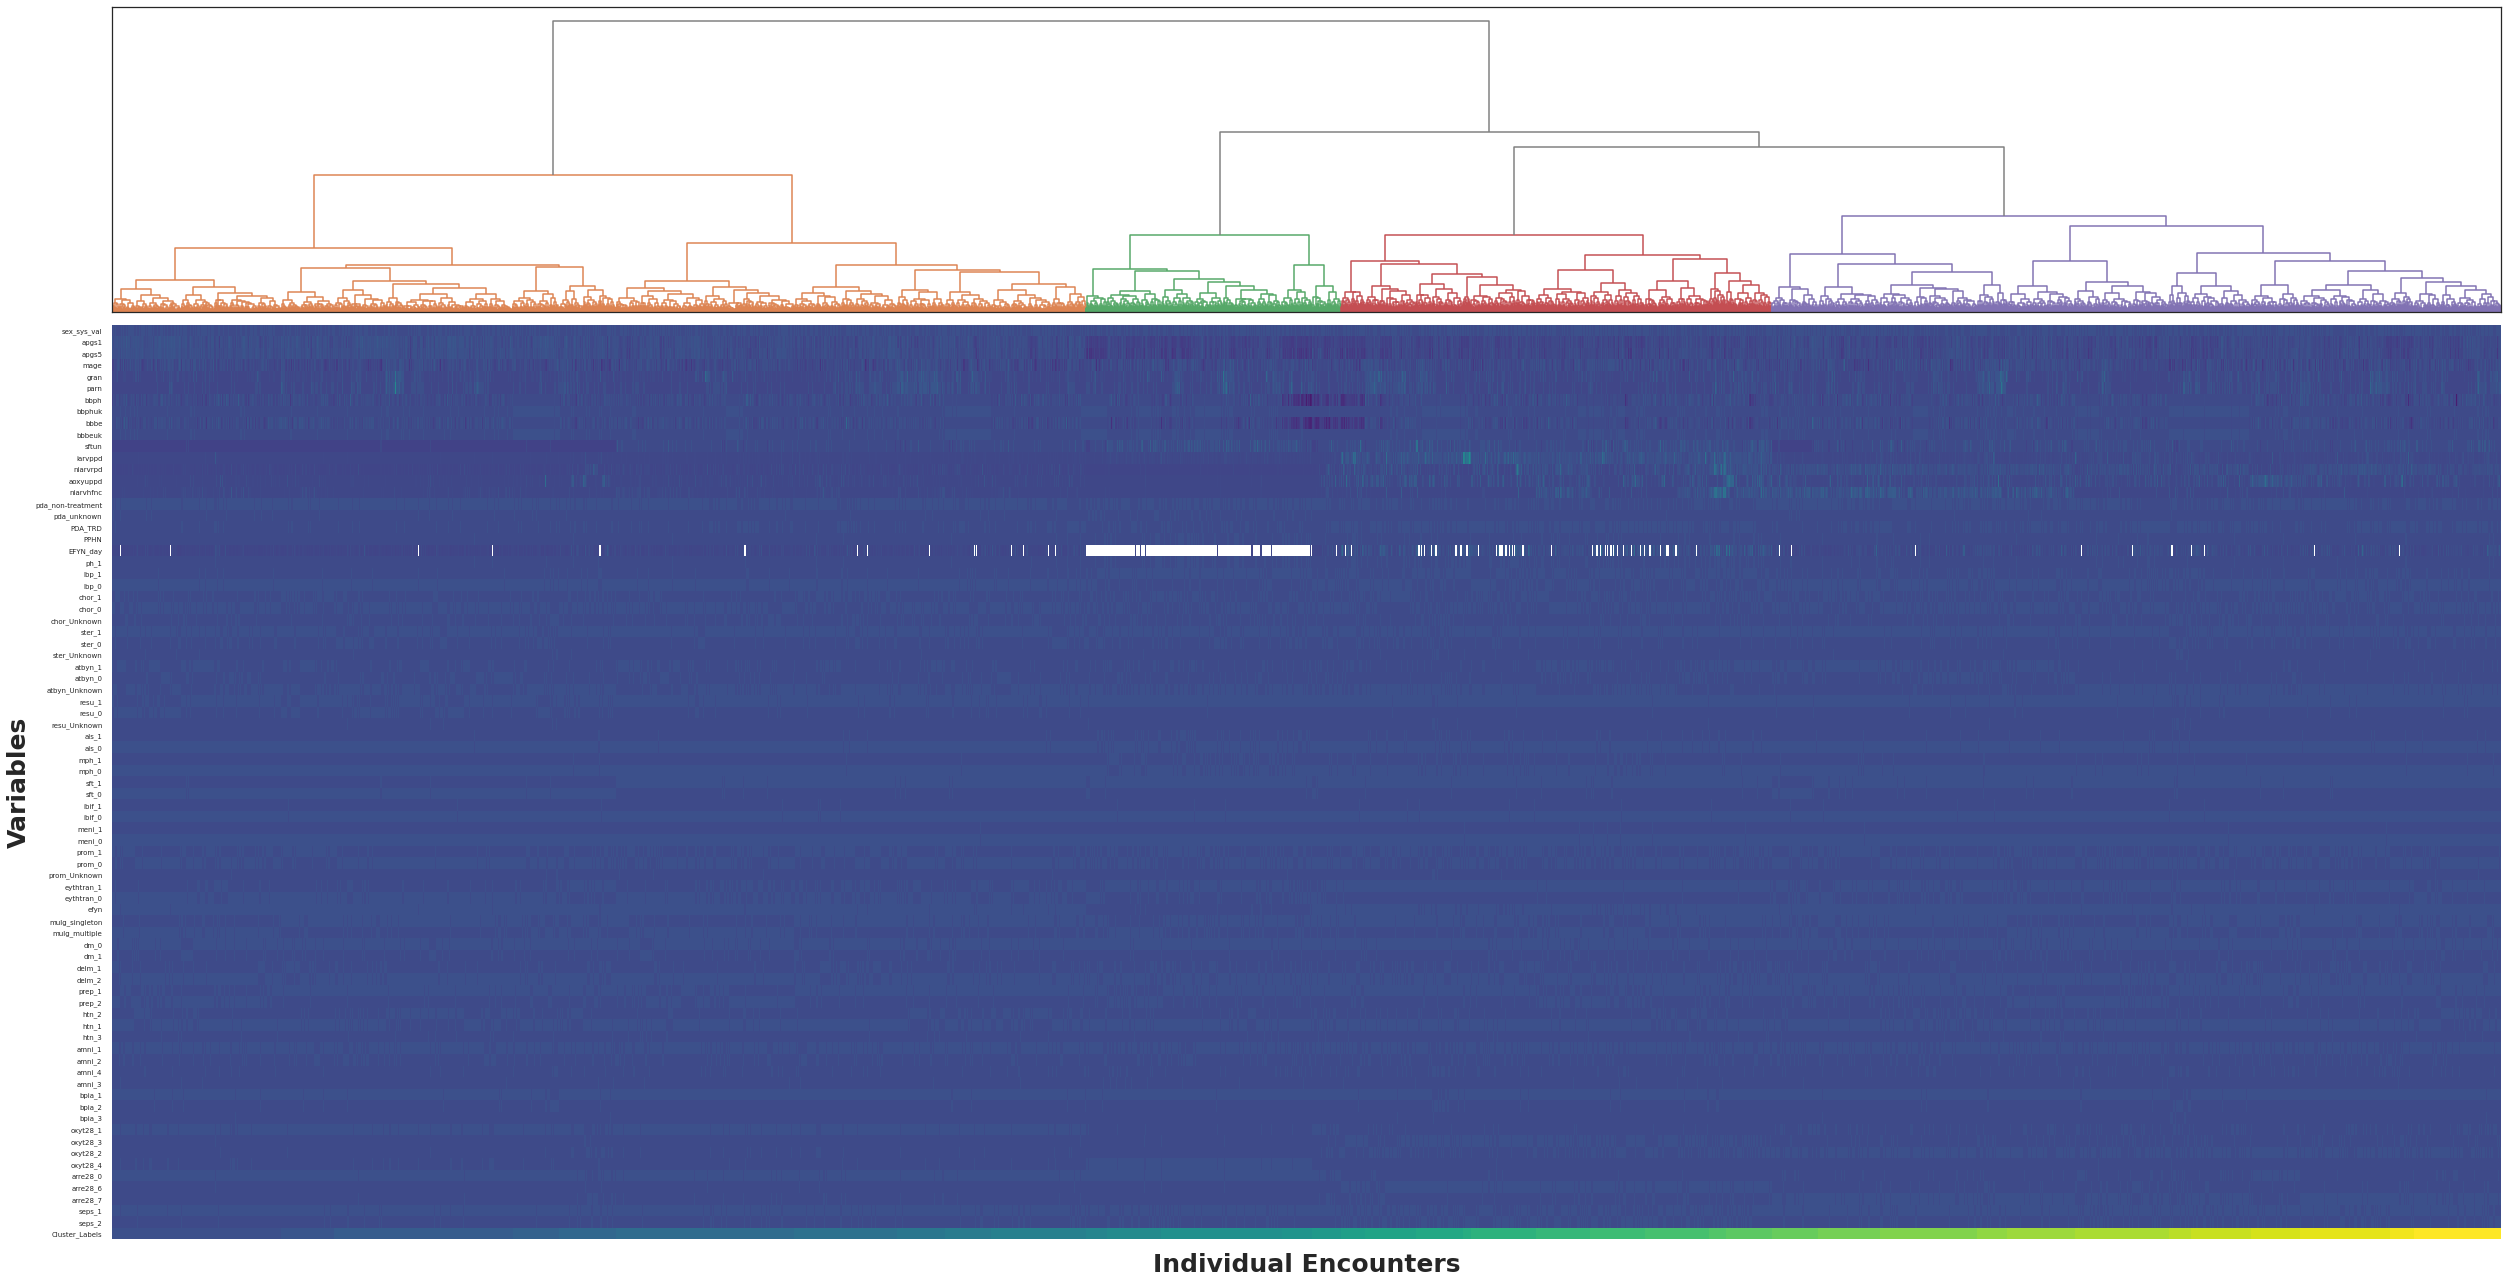

Dendrogram + Heatmap saved: path : /media/bami/d4960d77-e5f3-4877-a333-26e637be3a0e/JHA/24-07_nedis/KNN/Clustering/M15_dataset08/0531~/0711/WholeExp/cluster_analysis_scd.png
Clustering completed with 3 clusters.
          sex_sys_val     apgs1     apgs5      mage      gran      parn  \
idx_code                                                                  
0                   1 -0.361034 -1.032974 -1.020264 -0.760507 -0.636012   
1                   1 -0.361034 -1.032974  0.360486 -0.760507 -0.636012   
2                   1  0.117458 -0.497525 -1.710639 -0.760507 -0.636012   
3                   1  0.595950  0.037925 -1.710639 -0.760507 -0.636012   
4                   1 -0.361034 -1.032974  0.590611  1.748735  0.768667   
...               ...       ...       ...       ...       ...       ...   
20408               1  0.117458  0.573375 -2.401014 -0.760507 -0.636012   
20409               1 -0.361034  0.037925  1.050861  0.912321  0.768667   
20410               0  0.117458  0.037

In [102]:
## 재 클러스터링 with Z_objects : {n} Clusters
n_clusters = 4


# Z_objects 불러오기
with open(os.path.join(Z_dir, "Z_objects.pkl"), "rb") as f:
    Z_objects = pickle.load(f)

# 데이터프레임에서 death_label 칼럼 제외
data_for_clustering = df_scd.drop(columns=['death_label'])

cluster_labels = fcluster(Z_objects, t=n_clusters, criterion='maxclust')

# 각 클러스터에 할당된 샘플 수 확인
unique, counts = np.unique(cluster_labels, return_counts=True)
cluster_counts = dict(zip(unique, counts))
print(f"n_clusters = {n_clusters}: Cluster sizes = {cluster_counts}")

# 실루엣 점수 계산
silhouette_vals = silhouette_samples(data_for_clustering.fillna(0), cluster_labels)  # 개별 샘플의 실루엣 점수 계산
silhouette_avg = np.mean(silhouette_vals)  # 전체 실루엣 점수의 평균
silhouette_std_dev = np.std([np.mean(silhouette_vals[cluster_labels == label]) for label in np.unique(cluster_labels)])

# 실루엣 점수 및 표준 편차 출력
print(f"For n_clusters = {n_clusters},\nAverage Silhouette_score : {silhouette_avg:.4f},\nstd deviation: {silhouette_std_dev:.4f}\n")

# 시각화
sns.set(style="white")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(35, 18), gridspec_kw={'height_ratios': [1, 3]})

# Dendrogramme
threshold = Z_objects[-(n_clusters - 1), 2]
dendrogram(Z_objects
           , ax=ax1
           , orientation='top'
           , color_threshold=threshold
           , above_threshold_color='grey'
          )
ax1.set_xticks([])
ax1.set_yticks([])

sorted_idx = dendrogram(Z_objects, no_plot=True)['leaves']
data_sorted = data_for_clustering.iloc[sorted_idx]    ########

# Heatmap
sns.heatmap(data_sorted.T, ax=ax2, cbar=False, cmap='viridis', yticklabels=True)
ax2.set_xlabel('Individual Encounters', fontsize=25, fontweight='bold')
ax2.set_ylabel('Variables', fontsize=25, fontweight='bold')
ax2.set_xticklabels([])
ax2.tick_params(axis='y', labelsize=7)
plt.tight_layout()

plt.savefig(os.path.join(save_dir, "cluster_analysis_scd.png"))
plt.show()

plt.close(fig)
print(f"Dendrogram + Heatmap saved: path : {save_dir}/cluster_analysis_scd.png")

# 클러스터 라벨을 데이터프레임에 추가
df_scd['Cluster_Labels'] = cluster_labels

# # 원래 index였던 pid를 다시 붙이기
# df_scd['pid'] = df.index
# df_scd.set_index('pid', inplace=True)

df_scd['death_label'] = df['death_label']
# df_scd['Cluster_Labels_orn'] = original_cluster_labels    # 특정 클러스터를 사용하는 경우 사용

# 결과 출력
print("Clustering completed with 3 clusters.")
print(df_scd)

In [18]:
'''# {n} Level까지만 클러스터링
k_ = 2

data_for_clustering = df_scd.drop(columns=list(mortality))
print(df_scd.columns)
print(data_for_clustering.columns)

with open(os.path.join(save_dir, "Z_objects.pkl"), "rb") as f:
    Z_objects = pickle.load(f)

# 2nd Level 결과추출
cluster_labels_level_2 = fcluster(Z_objects, t=k_, criterion='maxclust')
print("Cluster labels at level 2:", cluster_labels_level_2)

# Cluster_label 추가
df_scd['Cluster_Labels'] = cluster_labels_level_2
print("Clustering completed with SCALED data.")
print(df_scd[['Cluster_Labels']])

# 시각화
sns.set(style="white")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(35, 18), gridspec_kw={'height_ratios': [1, 3]})

# 계층적 클러스터링의 덴드로그램 그리기
# Z_objects 로드 (이전에 저장한 Z_objects.pkl을 사용하셨다면 해당 파일 로드 필요)
with open(os.path.join(save_dir, "Z_objects.pkl"), "rb") as f:
    Z_objects = pickle.load(f)

# 2층 클러스터링 결과에 따른 threshold 계산
threshold = Z_objects[-2, 2]  # 2단계 클러스터링의 컷오프 높이 추출
dendrogram(Z_objects, ax=ax1, orientation='top', color_threshold=threshold, above_threshold_color='grey')
ax1.axhline(y=threshold, color='r', linestyle='--')  # 2층 분할 위치에 선 그리기
ax1.set_xticks([])
ax1.set_yticks([])

# 클러스터링 결과에 따른 데이터 정렬_
sorted_idx = dendrogram(Z_objects, no_plot=True)['leaves']
data_sorted = data_for_clustering.iloc[sorted_idx]  # 클러스터링 순서대로 데이터 정렬

# 히트맵 그리기
sns.heatmap(data_sorted.T, ax=ax2, cbar=False, cmap='viridis', yticklabels=True)
ax2.set_xlabel('Individual Encounters', fontsize=25, fontweight='bold')
ax2.set_ylabel('Variables', fontsize=25, fontweight='bold')
ax2.set_xticklabels([])
ax2.tick_params(axis='y', labelsize=20)
plt.tight_layout()

# 결과 저장 및 보여주기
plt.savefig(os.path.join(save_dir, "0814_cluster_analysis_scd.png"))
plt.show()

plt.close(fig)
print(f"Dendrogram + Heatmap saved: path : {save_dir}/0814_cluster_analysis_scd.png")

# 결과 저장
df_scd.to_csv(os.path.join(save_dir, "df_scd_clustered_level_2.csv"))'''

'# {n} Level까지만 클러스터링\nk_ = 2\n\ndata_for_clustering = df_scd.drop(columns=list(mortality))\nprint(df_scd.columns)\nprint(data_for_clustering.columns)\n\nwith open(os.path.join(save_dir, "Z_objects.pkl"), "rb") as f:\n    Z_objects = pickle.load(f)\n\n# 2nd Level 결과추출\ncluster_labels_level_2 = fcluster(Z_objects, t=k_, criterion=\'maxclust\')\nprint("Cluster labels at level 2:", cluster_labels_level_2)\n\n# Cluster_label 추가\ndf_scd[\'Cluster_Labels\'] = cluster_labels_level_2\nprint("Clustering completed with SCALED data.")\nprint(df_scd[[\'Cluster_Labels\']])\n\n# 시각화\nsns.set(style="white")\nfig, (ax1, ax2) = plt.subplots(2, 1, figsize=(35, 18), gridspec_kw={\'height_ratios\': [1, 3]})\n\n# 계층적 클러스터링의 덴드로그램 그리기\n# Z_objects 로드 (이전에 저장한 Z_objects.pkl을 사용하셨다면 해당 파일 로드 필요)\nwith open(os.path.join(save_dir, "Z_objects.pkl"), "rb") as f:\n    Z_objects = pickle.load(f)\n\n# 2층 클러스터링 결과에 따른 threshold 계산\nthreshold = Z_objects[-2, 2]  # 2단계 클러스터링의 컷오프 높이 추출\ndendrogram(Z_objects, ax=ax1, or

In [103]:
# df_scd.to_csv(os.path.join(out_0830, f"df\_scd_{best_n_clusters}clustered.csv"))
df_scd.to_csv(os.path.join(save_dir, f"df_scd_{n_clusters}clustered.csv"))

In [104]:
print(df_scd['Cluster_Labels'].value_counts().sort_index())
print(df_scd.isnull().sum())

1    8298
2    2174
3    3665
4    6215
Name: Cluster_Labels, dtype: int64
sex_sys_val       0
apgs1             0
apgs5             0
mage              0
gran              0
                 ..
arre28_7          0
seps_1            0
seps_2            0
death_label       0
Cluster_Labels    0
Length: 80, dtype: int64


In [105]:
df_scd.to_csv(os.path.join(save_dir, "df_scd_clustered.csv"))

In [106]:
## Merge Cluster_Labels to original dataframe
df_combined = df.merge(df_scd[['Cluster_Labels']]
                       , left_index=True, right_index=True
                       , how='left'
                      )
df_combined

,sex_sys_val,birthdt,bird,admd,apgs1,apgs5,bwei,mage,gran,parn,...,ntetoy_1,iperr_1,iperr_2,iperr_3,iperr_4,iperroy_1,iperroy_4,iperroy_3,iperroy_2,Cluster_Labels
idx_code,,,,,,,,,,,,,,,,,,,,,
0,1,2013-12-18,2013-12-18,2013-12-18,4.0,5.0,1350,29,1,0,...,0,1,0,0,0,1,0,0,0,1
1,1,2013-11-15,2013-11-15,2013-11-15,4.0,5.0,790,35,1,0,...,0,1,0,0,0,1,0,0,0,3
2,1,2013-11-15,2013-11-15,2013-11-15,5.0,6.0,1400,26,1,0,...,0,1,0,0,0,1,0,0,0,1
3,1,2013-11-15,2013-11-15,2013-11-15,6.0,7.0,1340,26,1,0,...,0,1,0,0,0,1,0,0,0,2
4,1,2013-11-11,2013-11-11,2013-11-11,4.0,5.0,1240,36,4,1,...,0,1,0,0,0,1,0,0,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20408,1,2022-11-28,2022-11-28,2022-11-28,5.0,8.0,1350,23,1,0,...,0,1,0,0,0,1,0,0,0,1
20409,1,2022-12-27,2022-12-27,2022-12-27,4.0,7.0,860,38,3,1,...,0,1,0,0,0,1,0,0,0,3
20410,0,2022-12-01,2022-12-01,2022-12-01,5.0,7.0,1910,30,2,0,...,0,1,0,0,0,1,0,0,0,4


In [107]:
df_combined.to_csv(os.path.join(save_dir, "KNN_df_combined.csv"))

In [108]:
# WILCOXON TEST

# Declare input data
input_df = df_combined

# 고유 클러스터 값과 클러스터 수 계산
unique_clusters = input_df['Cluster_Labels'].unique()
num_clusters = len(unique_clusters)

# 통계 및 p-값 저장용 DataFrame 생성
stats_df = pd.DataFrame()
p_values_df = pd.DataFrame()

# 각 클러스터 및 변수에 대한 계산
for i in unique_clusters:
    cluster_data = input_df[input_df['Cluster_Labels'] == i]
    outside_data = input_df[input_df['Cluster_Labels'] != i]
    stats = {}
    p_values = {}

    for column in input_df.columns[:-1]:  # 마지막 'Cluster_Labels' 제외
        if column != 'Cluster_Labels' and is_numeric_dtype(input_df[column]):
            valid_cluster_data = cluster_data[column].dropna()
            valid_outside_data = outside_data[column].dropna()

            # 두 집단 모두에서 유효한 데이터가 존재하고 모든 값이 같지 않을 때만 계산
            if len(valid_cluster_data) > 0 and len(valid_outside_data) > 0 and pd.concat([valid_cluster_data, valid_outside_data]).nunique() > 1:
                u_stat, p_value = mannwhitneyu(valid_cluster_data, valid_outside_data, alternative='two-sided')
                mean_val = valid_cluster_data.mean()
                std_dev = valid_cluster_data.std()

                # 결과 저장
                stats[column] = f"{mean_val:.4f} ± {std_dev:.4f}"
                if p_value < 0.01:
                    formatted_p_value = f"{p_value:.4e}" if p_value < 0.0001 else f"{p_value:.4f}"
                    p_values[column] = formatted_p_value
                else:
                    p_values[column] = "n.s."
            else:
                stats[column] = "NaN ± NaN"
                p_values[column] = "n.s."

    stats_df[f'Cluster {i}'] = pd.Series(stats)
    p_values_df[f'Cluster {i}'] = pd.Series(p_values)

# 결과를 DataFrame으로 결합
combined_df = pd.DataFrame()
for i in unique_clusters:
    combined_stats = stats_df[f'Cluster {i}'] + " (" + p_values_df[f'Cluster {i}'] + ")"
    combined_df[f'Cluster {i}'] = combined_stats

# Cluster 열을 이름을 기준으로 정렬
combined_df = combined_df.reindex(sorted(combined_df.columns), axis=1)

# 결과 출력
print("Combined Mean, Standard Deviation and P-values:")
print(combined_df)

Combined Mean, Standard Deviation and P-values:
                                     Cluster 1  \
sex_sys_val       0.4632 ± 0.4987 (1.8092e-21)   
apgs1             5.9150 ± 1.7800 (0.0000e+00)   
apgs5             7.8937 ± 1.2993 (0.0000e+00)   
bwei         1290.1546 ± 200.2696 (0.0000e+00)   
mage                   33.4123 ± 4.3265 (n.s.)   
...                                        ...   
iperr_4                 0.0000 ± 0.0000 (n.s.)   
iperroy_1         0.9965 ± 0.0590 (1.5977e-51)   
iperroy_4         0.0004 ± 0.0190 (6.6493e-08)   
iperroy_3         0.0030 ± 0.0548 (1.4684e-40)   
iperroy_2         0.0001 ± 0.0110 (1.0079e-05)   

                                    Cluster 2  \
sex_sys_val      0.5474 ± 0.4979 (1.4545e-05)   
apgs1            2.8379 ± 1.7627 (0.0000e+00)   
apgs5            5.0526 ± 2.2205 (0.0000e+00)   
bwei         815.7654 ± 301.8103 (0.0000e+00)   
mage                  33.2194 ± 4.5537 (n.s.)   
...                                       ...   
iperr_4 

In [96]:
'''
# Wilcoxon test :: features --> P-Value 순으로 정렬

unique_clusters = df_combined['Cluster_Labels'].unique()

# 통계 및 p-값 저장용 DataFrame 생성
stats_df = pd.DataFrame()
p_values_df = pd.DataFrame()

# 각 클러스터 및 변수에 대한 계산
for cluster in unique_clusters:
    cluster_data = df_combined[df_combined['Cluster_Labels'] == cluster]
    outside_data = df_combined[df_combined['Cluster_Labels'] != cluster]
    
    for column in df_combined.columns[:-1]:  # 마지막 'Cluster_Labels' 제외
        if column != 'Cluster_Labels' and is_numeric_dtype(df_combined[column]):
            valid_cluster_data = cluster_data[column].dropna()
            valid_outside_data = outside_data[column].dropna()

            # 두 집단 모두에서 유효한 데이터가 존재하고 모든 값이 같지 않을 때만 계산
            if len(valid_cluster_data) > 0 and len(valid_outside_data) > 0 and pd.concat([valid_cluster_data, valid_outside_data]).nunique() > 1:
                u_stat, p_value = mannwhitneyu(valid_cluster_data, valid_outside_data, alternative='two-sided')
                mean_val = valid_cluster_data.mean()
                std_dev = valid_cluster_data.std()

                # 결과 저장
                stats_df.loc[column, f'Cluster {cluster}'] = f"{mean_val:.4f} ± {std_dev:.4f}"
                p_values_df.loc[column, f'Cluster {cluster}'] = p_value
            else:
                stats_df.loc[column, f'Cluster {cluster}'] = "NaN ± NaN"
                p_values_df.loc[column, f'Cluster {cluster}'] = float('nan')

# 각 특성별 최소 p-value 계산
p_values_df['min_p_value'] = p_values_df.min(axis=1)

# p-value를 기준으로 행 정렬
p_values_df = p_values_df.sort_values(by='min_p_value')

# 정렬된 순서대로 최종 DataFrame 구성
combined_df = pd.DataFrame()
for column in p_values_df.columns[:-1]:  # 'min_p_value' 제외
    formatted_values = stats_df[column].reindex(p_values_df.index).astype(str) + " (" + p_values_df[column].reindex(p_values_df.index).apply(lambda x: f"{x:.4e}" if x < 0.0001 else f"{x:.4f}" if x == x else "n.s.").astype(str) + ")"
    combined_df[column] = formatted_values

# 결과 출력
print("Combined Mean, Standard Deviation and P-values (sorted by feature min p-value):")
print(combined_df)
'''

'\n# Wilcoxon test :: features --> P-Value 순으로 정렬\n\nunique_clusters = df_combined[\'Cluster_Labels\'].unique()\n\n# 통계 및 p-값 저장용 DataFrame 생성\nstats_df = pd.DataFrame()\np_values_df = pd.DataFrame()\n\n# 각 클러스터 및 변수에 대한 계산\nfor cluster in unique_clusters:\n    cluster_data = df_combined[df_combined[\'Cluster_Labels\'] == cluster]\n    outside_data = df_combined[df_combined[\'Cluster_Labels\'] != cluster]\n    \n    for column in df_combined.columns[:-1]:  # 마지막 \'Cluster_Labels\' 제외\n        if column != \'Cluster_Labels\' and is_numeric_dtype(df_combined[column]):\n            valid_cluster_data = cluster_data[column].dropna()\n            valid_outside_data = outside_data[column].dropna()\n\n            # 두 집단 모두에서 유효한 데이터가 존재하고 모든 값이 같지 않을 때만 계산\n            if len(valid_cluster_data) > 0 and len(valid_outside_data) > 0 and pd.concat([valid_cluster_data, valid_outside_data]).nunique() > 1:\n                u_stat, p_value = mannwhitneyu(valid_cluster_data, valid_outside_data, alter

In [109]:
combined_df.to_csv(os.path.join(save_dir, "KNN_df_combined_wilcoxon+p_val.csv")
                   , encoding='utf-8-sig'    # '±'표현을 위해 encoding='utf-8-sig' 사용
                  )

In [110]:
## DEATH RATIO
# 'Cluster_Labels'와 'death_label' 확인
def calculate_positive_rate(ipt_df, ipt_col):
    # 'Cluster_Labels'와 ipt_col 확인
    if 'Cluster_Labels' in ipt_df.columns and ipt_col in ipt_df.columns:
        results_df = pd.DataFrame()

        # 각 클러스터의 Positive Rate 계산
        for i in sorted(ipt_df['Cluster_Labels'].unique()):  # Cluster_Labels 번호 순서대로 정렬
            cluster_data = ipt_df[ipt_df['Cluster_Labels'] == i]
            total_count = cluster_data.shape[0]
            positive_count = (cluster_data[ipt_col] == 1).sum()
            negative_count = (cluster_data[ipt_col] == 0).sum()

            # 칼럼 이름에서 언더바 이후를 제거
            display_col = ipt_col.split('_')[0]

            # Positive Rate 계산
            positive_rate = (positive_count / total_count) * 100

            # 결과 저장
            results_df.loc[f'Cluster {i}', 'Total'] = total_count
            results_df.loc[f'Cluster {i}', f'{display_col}_Pos'] = positive_count
            results_df.loc[f'Cluster {i}', f'{display_col}_Neg'] = negative_count
            results_df.loc[f'Cluster {i}', 'Positive Rate'] = f"{positive_rate:.2f}%"
            results_df.loc[f'Cluster {i}', f'{display_col}_Pos / Total'] = f"{positive_count} / {total_count}"

        # 결과 출력
        return results_df
    else:
        return f"Dataframe does not contain required columns 'Cluster_Labels' and '{ipt_col}'"


# iperr_3
# iperr_4

# ntet_1
# iperr_2
# death36
cmr = calculate_positive_rate(df_combined, 'death_label')
cmr1 = calculate_positive_rate(df_combined, 'ntet_1')
cmr2 = calculate_positive_rate(df_combined, 'iperr_2')
print(cmr, cmr1, cmr2)

            Total  death_Pos  death_Neg Positive Rate death_Pos / Total
Cluster 1  8298.0      112.0     8186.0         1.35%        112 / 8298
Cluster 2  2174.0     1856.0      318.0        85.37%       1856 / 2174
Cluster 3  3665.0      511.0     3154.0        13.94%        511 / 3665
Cluster 4  6215.0      112.0     6103.0         1.80%        112 / 6215             Total  ntet_Pos  ntet_Neg Positive Rate ntet_Pos / Total
Cluster 1  8298.0     169.0    8129.0         2.04%       169 / 8298
Cluster 2  2174.0     211.0    1963.0         9.71%       211 / 2174
Cluster 3  3665.0     558.0    3107.0        15.23%       558 / 3665
Cluster 4  6215.0     344.0    5871.0         5.53%       344 / 6215             Total  iperr_Pos  iperr_Neg Positive Rate iperr_Pos / Total
Cluster 1  8298.0       29.0     8269.0         0.35%         29 / 8298
Cluster 2  2174.0       75.0     2099.0         3.45%         75 / 2174
Cluster 3  3665.0      246.0     3419.0         6.71%        246 / 3665
Cluster

In [111]:
cmr.to_csv(os.path.join(save_dir, "mortality_rate_results_death36.csv"), encoding='utf-8-sig')
cmr1.to_csv(os.path.join(save_dir, "mortality_rate_results_ntetPos.csv"), encoding='utf-8-sig')
cmr2.to_csv(os.path.join(save_dir, "mortality_rate_results_iperrPos.csv"), encoding='utf-8-sig')

In [112]:
# Result function : 'n' about 2+ Cols

def calculate_positive_rate(ipt_df, ipt_cols):
    # 'Cluster_Labels'와 ipt_cols가 존재하는지 확인
    if 'Cluster_Labels' in ipt_df.columns and all(col in ipt_df.columns for col in ipt_cols):
        results_df = pd.DataFrame()

        # 두 칼럼 전부 1인 경우를 Positive로 간주 ('And' Condition)
        ipt_df['combined_Positive'] = (ipt_df[ipt_cols[0]] == 1) & (ipt_df[ipt_cols[1]] == 1)

        # 각 클러스터별 Positive Rate 계산
        for i in sorted(ipt_df['Cluster_Labels'].unique()):  # Cluster_Labels 번호 순서대로 정렬
            cluster_data = ipt_df[ipt_df['Cluster_Labels'] == i]
            total_count = cluster_data.shape[0]
            positive_count = cluster_data['combined_Positive'].sum()
            negative_count = total_count - positive_count

            # 칼럼 이름 조합하여 표시
            display_col = "_and_".join([col.split('_')[0] for col in ipt_cols])

            # Positive Rate 계산
            positive_rate = (positive_count / total_count) * 100

            # 결과 저장
            results_df.loc[f'Cluster {i}', 'Total'] = total_count
            results_df.loc[f'Cluster {i}', f'{display_col}_Pos'] = positive_count
            results_df.loc[f'Cluster {i}', f'{display_col}_Neg'] = negative_count
            results_df.loc[f'Cluster {i}', 'Positive Rate'] = f"{positive_rate:.2f}%"
            results_df.loc[f'Cluster {i}', f'{display_col}_Pos / Total'] = f"{positive_count} / {total_count}"

        # 'combined_Positive' 칼럼 삭제 (원본 유지)
        ipt_df.drop(columns=['combined_Positive'], inplace=True)

        # 결과 출력
        return results_df
    else:
        return f"Dataframe does not contain required columns 'Cluster_Labels' and {ipt_cols}"

# 사용 예시
cmr3 = calculate_positive_rate(df_combined, ['ntet_1', 'iperr_2'])
print(cmr3)

            Total  ntet_and_iperr_Pos  ntet_and_iperr_Neg Positive Rate  \
Cluster 1  8298.0                 7.0              8291.0         0.08%   
Cluster 2  2174.0                23.0              2151.0         1.06%   
Cluster 3  3665.0                87.0              3578.0         2.37%   
Cluster 4  6215.0                29.0              6186.0         0.47%   

          ntet_and_iperr_Pos / Total  
Cluster 1                   7 / 8298  
Cluster 2                  23 / 2174  
Cluster 3                  87 / 3665  
Cluster 4                  29 / 6215  


In [113]:
cmr3.to_csv(os.path.join(save_dir, "mortality_rate_results_iperr&ntet.csv"), encoding='utf-8-sig')